In [1]:
## Importing Libraries

import os
import copy
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
## Creating Random Seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed Set Successfully.")

Random Seed Set Successfully.


In [3]:
## Setting Up GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

if device.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))


Device : cuda
GPU : NVIDIA GeForce RTX 5050 Laptop GPU


In [ ]:
## Setting Paths

DATASET_PATH = r"Dataset"

TRAIN_CSV = os.path.join(DATASET_PATH, "train.csv")
TEST_CSV = os.path.join(DATASET_PATH, "test.csv")

In [5]:
## Loading Dataset

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)

Training Shape : (1785, 9)
Testing Shape : (5, 3)


In [6]:
## Pivoting Dataset

pivot_df = train_df.pivot(index="image_path", columns="target_name", values="target").reset_index()
display(pivot_df.head())

target_name,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605


In [7]:
## Creating Target Columns

TARGET_COLUMNS = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"]

In [8]:
## Splitting Data in Training and Validating

train_data, valid_data = train_test_split(pivot_df, test_size=0.20, random_state=SEED, shuffle=True)

print("Training Images :", len(train_data))
print("Validation Images :", len(valid_data))

Training Images : 285
Validation Images : 72


In [9]:
## Creating Hyperparameters

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 512

BATCH_SIZE = 8
LEARNING_RATE = 1e-4

EPOCHS = 50
NUM_WORKERS = 0

In [10]:
## Creating Image Transformers

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [11]:
## Creatinfg BiomassDataset Class

class BiomassDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = os.path.join(DATASET_PATH, row["image_path"])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        target = torch.tensor(row[TARGET_COLUMNS].values.astype(np.float32))

        return image, target

In [12]:
## Settting Dataset objects

train_dataset = BiomassDataset(train_data, transform=train_transform)

valid_dataset = BiomassDataset(valid_data, transform=valid_transform)

In [13]:
## Creating DataLoaders

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

In [14]:
## Verifying Pipeline

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([8, 3, 256, 512])
Label Batch Shape : torch.Size([8, 5])


In [15]:
## Loading Pretrained EfficientNet-B3

weights = models.EfficientNet_B3_Weights.DEFAULT
model = models.efficientnet_b3(weights = weights)

print("Pretrained EfficientNet-B3 Loaded Successfully.")

Pretrained EfficientNet-B3 Loaded Successfully.


In [16]:
## Original Classifier

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)


In [17]:
## Replacing Classifier

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, 512),
    nn.ReLU(),

    nn.Dropout(0.20),
    nn.Linear(512, 128),
    nn.ReLU(),

    nn.Linear(128, 5)
)

print("Regression Head Added Successfully.")

Regression Head Added Successfully.


In [18]:
## Sending Model to Device

model = model.to(device)
print("Model Loaded on", device)

Model Loaded on cuda


In [19]:
## Model Architecture

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
        

In [20]:
## Model Parameters

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 50)
print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print("=" * 50)

Total Parameters      : 11,549,485
Trainable Parameters  : 11,549,485


In [21]:
## Loss Function

criterion = nn.MSELoss()
print("Loss Function : MSELoss")

Loss Function : MSELoss


In [22]:
## Optimizer

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print("Optimizer : AdamW")

Optimizer : AdamW


In [23]:
## Learning Rate Scheduler

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

print("Learning Rate Scheduler Ready.")

Learning Rate Scheduler Ready.


In [24]:
## Forward Pass Test

model.eval()

with torch.no_grad():
    images, labels = next(iter(train_loader))
    images = images.to(device)
    outputs = model(images)

print("Input Shape  :", images.shape)
print("Output Shape :", outputs.shape)
print("Label Shape  :", labels.shape)

Input Shape  : torch.Size([8, 3, 256, 512])
Output Shape : torch.Size([8, 5])
Label Shape  : torch.Size([8, 5])


In [25]:
## Training Variables

best_loss = np.inf

train_losses = []
valid_losses = []

print("Training Variables Initialized.")

Training Variables Initialized.


In [26]:
## Training Configuration 

print("=" * 50)
print("Model Training Configuration")
print("=" * 50)

print(f"Model                : EfficientNet-B3")
print(f"Output Features      : {len(TARGET_COLUMNS)}")
print(f"Image Size           : {IMAGE_HEIGHT} x {IMAGE_WIDTH}")
print(f"Batch Size           : {BATCH_SIZE}")
print(f"Epochs               : {EPOCHS}")
print(f"Learning Rate        : {LEARNING_RATE}")

print(f"Optimizer            : AdamW")
print(f"Loss Function        : MSELoss")
print(f"Scheduler            : ReduceLROnPlateau")


Model Training Configuration
Model                : EfficientNet-B3
Output Features      : 5
Image Size           : 256 x 512
Batch Size           : 8
Epochs               : 50
Learning Rate        : 0.0001
Optimizer            : AdamW
Loss Function        : MSELoss
Scheduler            : ReduceLROnPlateau


In [27]:
## Creating Training Function

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [28]:
## Creating Validation Function

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [29]:
## Training History

history = {"train_loss": [], "valid_loss": []}

In [30]:
## Clarifying Best Model

best_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())

In [31]:
## Creating Training Loop

print("=" * 50)
print("Training Started")
print("=" * 50)

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    valid_loss = validate_one_epoch(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    print(
        f"Epoch [{epoch+1:02}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {valid_loss:.4f}"
    )

    if valid_loss < best_loss:
        best_loss = valid_loss

        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "model.pth")

        print("Best Model Saved.")

Training Started
Epoch [01/50] | Train Loss: 1276.2182 | Validation Loss: 944.1603
Best Model Saved.
Epoch [02/50] | Train Loss: 866.6036 | Validation Loss: 625.1199
Best Model Saved.
Epoch [03/50] | Train Loss: 450.0909 | Validation Loss: 434.9962
Best Model Saved.
Epoch [04/50] | Train Loss: 314.0119 | Validation Loss: 288.9788
Best Model Saved.
Epoch [05/50] | Train Loss: 279.3890 | Validation Loss: 254.0848
Best Model Saved.
Epoch [06/50] | Train Loss: 245.7541 | Validation Loss: 234.9073
Best Model Saved.
Epoch [07/50] | Train Loss: 265.1813 | Validation Loss: 255.4050
Epoch [08/50] | Train Loss: 251.7469 | Validation Loss: 218.7753
Best Model Saved.
Epoch [09/50] | Train Loss: 215.2316 | Validation Loss: 227.7855
Epoch [10/50] | Train Loss: 227.8715 | Validation Loss: 208.3053
Best Model Saved.
Epoch [11/50] | Train Loss: 220.5004 | Validation Loss: 210.3448
Epoch [12/50] | Train Loss: 215.2691 | Validation Loss: 219.1531
Epoch [13/50] | Train Loss: 216.3216 | Validation Loss: 21

In [32]:
## Saving Training History

history_df = pd.DataFrame(history)
history_df.to_csv("training_history.csv", index=False)

print("Training History Saved.")

Training History Saved.


In [33]:
print("=" * 50)
print("Model Training Summary")
print("=" * 50)

print(f"Best Validation Loss : {best_loss:.4f}")
print(f"Epochs               : {EPOCHS}")
print(f"Learning Rate        : {LEARNING_RATE}")


Model Training Summary
Best Validation Loss : 163.3323
Epochs               : 50
Learning Rate        : 0.0001


In [35]:
## Generating Predictions

model.eval()

predictions = []
ground_truth = []

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = model(images)

        predictions.extend(outputs.cpu().numpy())
        ground_truth.extend(labels.numpy())

predictions = np.array(predictions)
ground_truth = np.array(ground_truth)

print("Prediction Shape :", predictions.shape)
print("Ground Truth Shape :", ground_truth.shape)

Prediction Shape : (72, 5)
Ground Truth Shape : (72, 5)


In [37]:
## All Evaluation Metrics

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
mae = mean_absolute_error(ground_truth, predictions)
mse = mean_squared_error(ground_truth, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(ground_truth, predictions)

print("=" * 50)
print("Evaluation Results: ")
print("=" * 50)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Evaluation Results: 
MAE  : 8.6724
MSE  : 172.2744
RMSE : 13.1253
R2   : 0.4585


In [38]:
## Performance Per Target

results = []

for i, target in enumerate(TARGET_COLUMNS):
    mae = mean_absolute_error(ground_truth[:, i], predictions[:, i])
    mse = mean_squared_error(ground_truth[:, i], predictions[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(ground_truth[:, i], predictions[:, i])

    results.append([target, mae, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["Target", "MAE", "MSE", "RMSE", "R2 Score"])

display(results_df)

,Target,MAE,MSE,RMSE,R2 Score
0,Dry_Clover_g,6.718764,120.800415,10.990924,0.322150
1,Dry_Dead_g,7.643409,119.252060,10.920259,0.175553
2,Dry_Green_g,8.637385,188.346954,13.723955,0.599556
3,Dry_Total_g,11.825027,264.364532,16.259291,0.545951
4,GDM_g,8.537489,168.608231,12.984923,0.649397


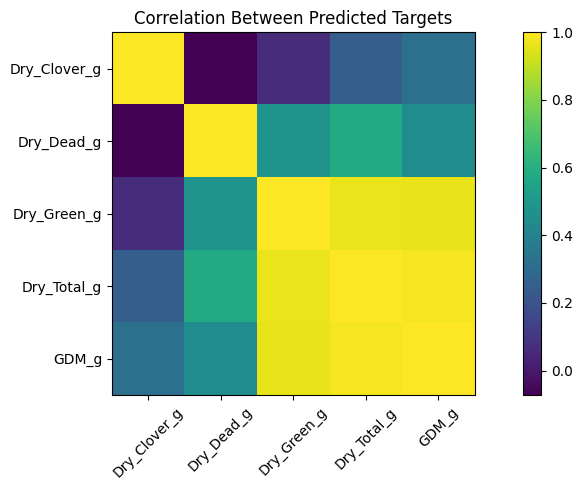

In [39]:
## Prediction Correlation Heatmap

correlation = pd.DataFrame(predictions, columns=TARGET_COLUMNS).corr()

plt.figure(figsize=(10, 5))

plt.imshow(correlation, cmap="viridis", interpolation="nearest")
plt.xticks(range(len(TARGET_COLUMNS)), TARGET_COLUMNS, rotation=45)
plt.yticks(range(len(TARGET_COLUMNS)), TARGET_COLUMNS)

plt.colorbar()
plt.title("Correlation Between Predicted Targets")
plt.tight_layout()
plt.show()

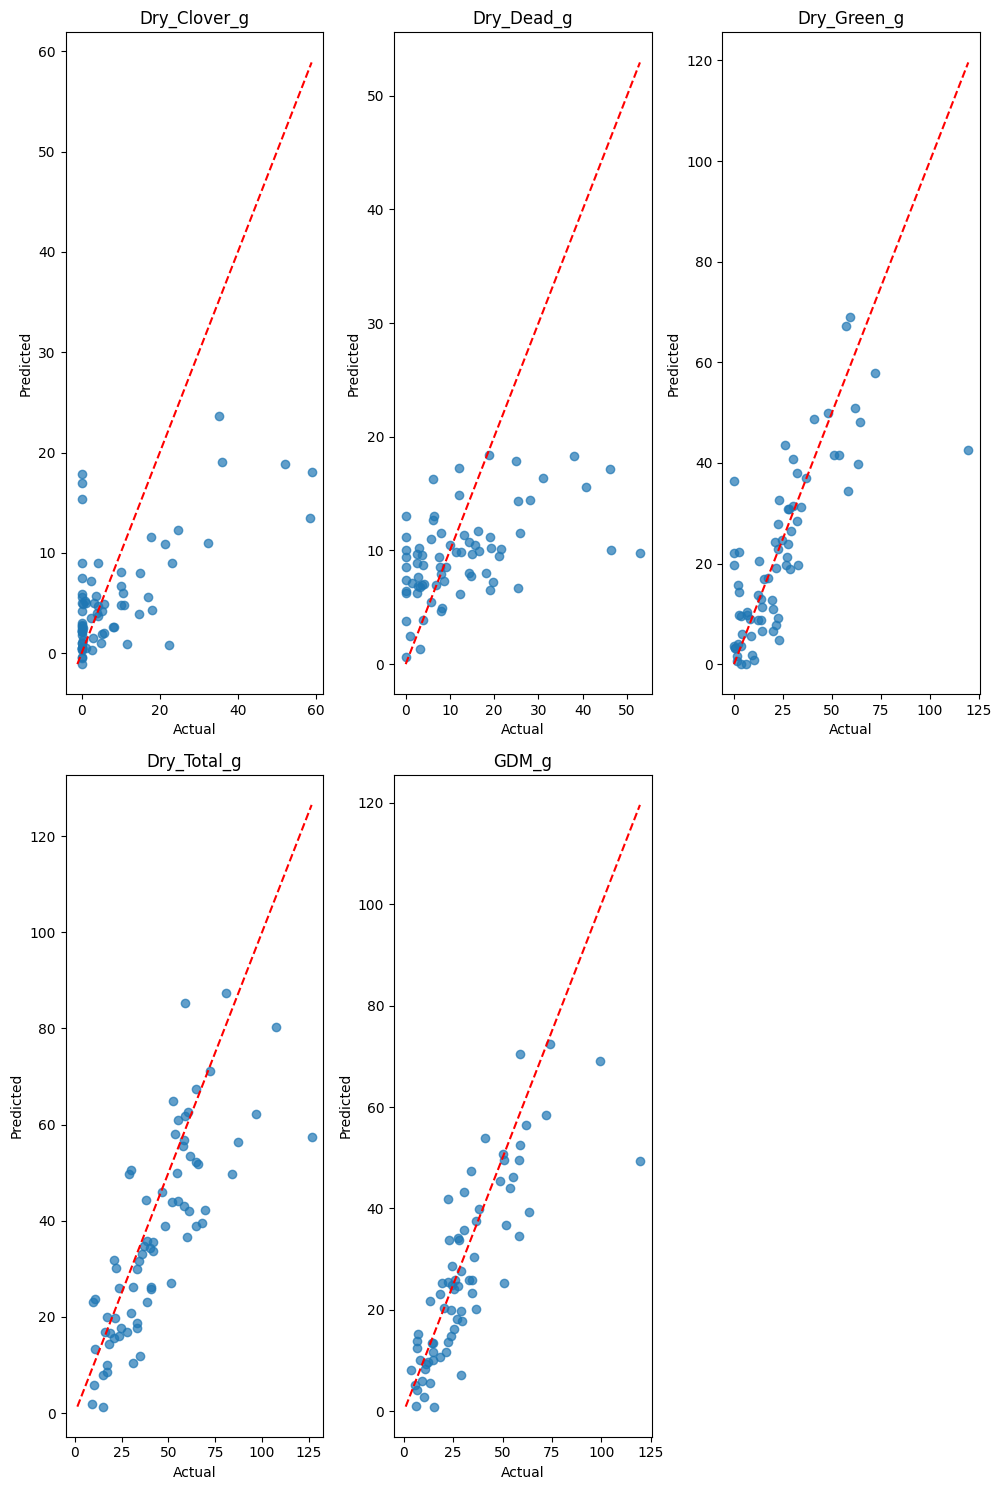

In [40]:
## Predicted vs Actual

fig, axes = plt.subplots(2, 3, figsize=(10, 15))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLUMNS):
    axes[i].scatter(ground_truth[:, i], predictions[:, i], alpha=0.7)
    minimum = min(ground_truth[:, i].min(), predictions[:, i].min())
    maximum = max(ground_truth[:, i].max(), predictions[:, i].max())

    axes[i].plot([minimum, maximum], [minimum, maximum], "r--")

    axes[i].set_title(target)
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

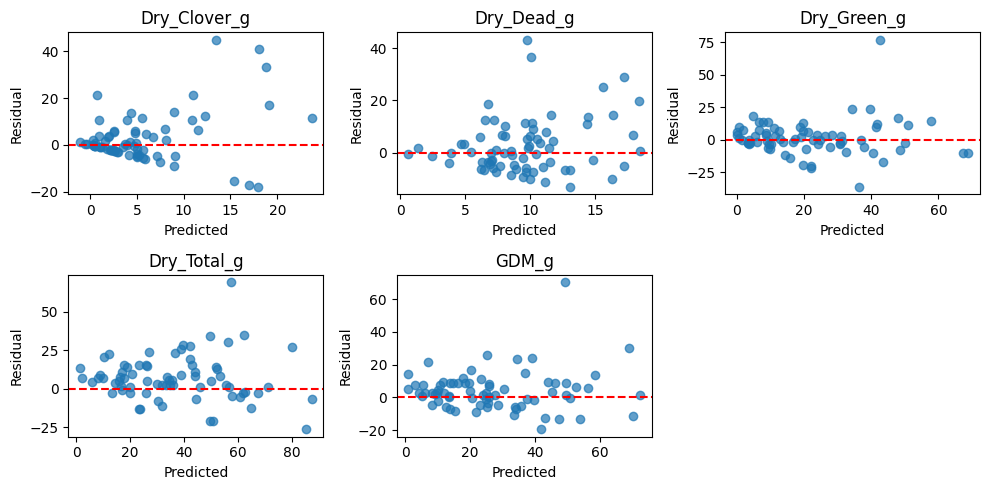

In [41]:
## Residual Analysis

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLUMNS):
    residuals = (ground_truth[:, i] - predictions[:, i])

    axes[i].scatter(predictions[:, i], residuals, alpha=0.7)
    axes[i].axhline(0, color="red", linestyle = "--")

    axes[i].set_title(target)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

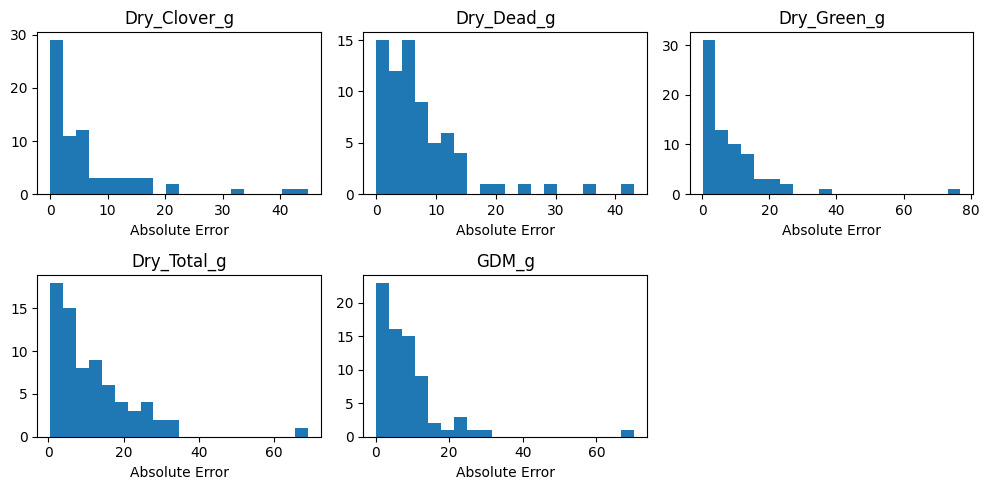

In [42]:
## Error Distribution

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLUMNS):
    errors = np.abs(ground_truth[:, i] - predictions[:, i])

    axes[i].hist(errors, bins=20)
    axes[i].set_title(target)
    axes[i].set_xlabel("Absolute Error")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [46]:
## Saving Evaluation Metrics

results_df.to_csv("evaluation_metrics.csv", index = False)

print("Evaluation Metrics Saved Successfully.")

Evaluation Metrics Saved Successfully.


In [47]:
print("=" * 60)
print("Training And Evaluation is completed.")
print("=" * 60)

print(f"Validation Samples : {len(valid_dataset)}")
print(f"Overall MAE        : {mae:.4f}")
print(f"Overall RMSE       : {rmse:.4f}")
print(f"Overall R² Score   : {r2:.4f}")

print()
print("Best Model Saved Successfully.")
print("Evaluation Completed Successfully.")


Training And Evaluation is completed.
Validation Samples : 72
Overall MAE        : 8.5375
Overall RMSE       : 12.9849
Overall R² Score   : 0.6494

Best Model Saved Successfully.
Evaluation Completed Successfully.
